<a href="https://colab.research.google.com/github/yfpang7/dataScience_Practice/blob/main/XavierKaiming_initialization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import polars as pl
import polars.selectors as cs
import numpy as np

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

import altair as alt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
import sklearn.metrics as skm

import copy
import shap

pl.Config.set_tbl_cols(-1)

polars.config.Config

In [2]:
!pip install --upgrade "kaleido==0.1.*"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 MB 12.8 MB/s eta 0:00:00


In [3]:
import plotly.io as pio
pio.renderers.default = 'svg'

In [4]:
# importing the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

raw_data = pl.read_csv(url, separator=';', infer_schema_length=10000)

raw_data.head()

fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
7.4,0.7,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.2,0.68,9.8,5
7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.997,3.26,0.65,9.8,5
11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.998,3.16,0.58,9.8,6
7.4,0.7,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
# remove the spacing in sugar columns
raw_data = raw_data.rename({col : col.replace(" ", "_") for col in raw_data.columns})

In [6]:
# create a new columnn to convert quality to two binaries: 1 for good quality and 0 for bad quality
raw_data = (
    raw_data
    .with_columns(
        new_quality=pl.when(pl.col('quality') > 5)
        .then(pl.lit(1))
        .otherwise(pl.lit(0))
    )
)

In [7]:
# prepare features and labels
features = raw_data.drop('quality', 'new_quality').to_numpy()
labels = raw_data.select('new_quality').to_numpy().squeeze()

# split the data BEFORE scaling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.1, random_state=42)

# scale the features (fit only on training data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
features.shape

(1599, 11)

In [9]:
# convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.int64)
y_test_tensor = torch.tensor(y_test, dtype=torch.int64)

In [10]:
# create dataloaders
train_data = TensorDataset(X_train_tensor, y_train_tensor)
test_data = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [11]:
# create ANN model
class ANNModel(nn.Module):
  def __init__(
      self,
      input_size,
      hidden_size,
      n_hidden_layers,
      output_size=1,
      activation='relu',
      output_activation=None,
      dropout=0.0,
      input_dropout=False
  ):

    super().__init__()

    activations = {
        'relu' : nn.ReLU(),
        "tanh" : nn.Tanh(),
        "sigmoid" : nn.Sigmoid(),
        "leakyrelu": nn.LeakyReLU(),
    }
    # default nn.ReLU() if none found
    self.activation = activations.get(activation.lower(), nn.ReLU())

    layers = []

    # input layer
    layers.append(nn.Linear(input_size, hidden_size))
    if input_dropout and dropout > 0:
      layers.append(nn.Dropout(dropout))

    # hidden layers
    for _ in range(n_hidden_layers):
      layers.append(nn.Linear(hidden_size, hidden_size))
      if dropout > 0:
        layers.append(nn.Dropout(dropout))

    # output layer
    layers.append(nn.Linear(hidden_size, output_size))

    self.layers = nn.ModuleList(layers)
    self.output_activation = output_activation

  def forward(self, x):
    # process al layers except output
    # check for linear layer (a fully connected)
    # if this layer object an instance of nn.Linear()
    for layer in self.layers[:-1]:
      if isinstance(layer, nn.Linear):
        x = self.activation(layer(x))
      else:
        # if anythign else just pass the data through the dropout layer
        x = layer(x)

    # output layer
    x = self.layers[-1](x)

    # apply output activatio if specific - default is None
    if self.output_activation:
      if self.output_activation.lower() == 'sigmoid':
        x = torch.sigmoid(x)
      elif self.output_activation.lower() == 'softmax':
        x = F.softmax(x, dim=1)
      # to add more activations here

    return x

In [12]:
def create_ann_network(
    input_size,
    hidden_size,  # renamed from nUnits for clarity
    n_hidden_layers,  # renamed from nLayers for clarity
    learning_rate=0.01,
    task="regression",   # "regression", "binary", "multiclass"
    num_classes=2,       # default to 2 for binary
    activation="relu",
    dropout=0.0,
    optimizer_type="adam",
    scheduler_step=10,
    scheduler_gamma=0.95,
    weights_initialization='xavier' # xavier: tanh, sigmid / kaiming: relu
):
    """
    Create a complete ANN setup with model, loss, optimizer, and scheduler.

    Args:
        input_size: Number of input features
        hidden_size: Number of units in hidden layers
        n_hidden_layers: Number of hidden layers (excluding input/output)
        learning_rate: Learning rate for optimizer
        task: Type of task - "regression", "binary", or "multiclass"
        num_classes: Number of classes (for multiclass only)
        activation: Activation function for hidden layers
        dropout: Dropout probability
        optimizer_type: Type of optimizer ("adam", "sgd", "rmsprop")
        scheduler_step: Step size for learning rate scheduler
        scheduler_gamma: Gamma for learning rate scheduler,
        weights_initialization: Type of weights initialization ("kaiming", "xavier")

    """

    # Configure output settings based on task
    if task == "regression":
        output_size = 1
        output_activation = None
        loss_func = nn.MSELoss()

    elif task == "binary":
        output_size = 1
        output_activation = None  # Use logits with BCEWithLogitsLoss
        loss_func = nn.BCEWithLogitsLoss()  # More numerically stable

    elif task == "multiclass":
        output_size = num_classes
        output_activation = None  # Use logits with CrossEntropyLoss
        loss_func = nn.CrossEntropyLoss()

    else:
        raise ValueError("task must be 'regression', 'binary', or 'multiclass'")

    # Build model
    model = ANNModel(
        input_size=input_size,
        hidden_size=hidden_size,
        n_hidden_layers=n_hidden_layers,
        output_size=output_size,
        activation=activation,
        output_activation=output_activation,
        dropout=dropout
    )

    # change the weights (leave the biases as Kaiming, which is Pytorch default)
    if weights_initialization == 'xavier':
      for name, param in model.named_parameters():
        if 'weight' in name:
          nn.init.xavier_normal_(param.data)
    elif weights_initialization == 'kaiming':
      for name, param in model.named_parameters():
        if 'weight' in name:
          nn.init.kaiming_uniform_(param.data, nonlinearity='relu')
    else:
      raise ValueError("tmust be 'kaiming', or 'xavier'")



    # Create optimizer
    optimizers = {
        "adam": torch.optim.Adam,
        "sgd": torch.optim.SGD,
        "rmsprop": torch.optim.RMSprop
    }

    optimizer_class = optimizers.get(optimizer_type.lower(), torch.optim.Adam)
    optimizer = optimizer_class(model.parameters(), lr=learning_rate)

    # Create scheduler
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=scheduler_step,
        gamma=scheduler_gamma
    )

    return model, loss_func, optimizer, scheduler

In [13]:
# add the different initialization kaiming vs xavier
def trainModel(
    train_loader,
    test_loader,
    input_size,
    hidden_size=32,
    n_hidden_layers=2,
    learning_rate=0.01,
    task="regression",
    num_classes=2,
    activation="relu",
    dropout=0.0,
    optimizer_type="adam",
    scheduler_step=10,
    scheduler_gamma=0.95,
    numepochs=100,
    toggleDynamic=False,
    weights_initialization='xavier'
):

  training_progress = pl.DataFrame(
      schema=[
          ('iteration', pl.Int64),
          ('epoch', pl.Int64),
          ('train_loss', pl.Float64),
          ('train_acc', pl.Float64),
          ('test_loss', pl.Float64),
          ('test_acc', pl.Float64),
          ('learning_rate', pl.Float64)
      ]
  )
  iteration = 0
  # create the ann model
  model, loss_func, optimizer, scheduler = create_ann_network(
    input_size,
    hidden_size,
    n_hidden_layers,
    learning_rate,
    task,
    num_classes,
    activation,
    dropout,
    optimizer_type,
    scheduler_step,
    scheduler_gamma,
    weights_initialization
  )

  # early stopping parameters
  patience =  15
  best_loss = float('inf')
  no_improve_count = 0
  best_model = None

  # training loop
  for epoch in range(numepochs):
    model.train()
    epoch_train_loss = 0
    epoch_train_acc = 0
    num_batches = 0

    # iterate through the training batches
    for X_trainTL, y_trainTL in train_loader:
      yhat_train = model(X_trainTL)


      # Handle different task types for loss calculation
      if task == "multiclass":
        train_loss = loss_func(yhat_train, y_trainTL)
      else:
        train_loss = loss_func(yhat_train.squeeze(), y_trainTL.float())

      ## backpropagation
      optimizer.zero_grad()
      train_loss.backward()
      optimizer.step()
      ## evaluate training accuracy
      if task == "multiclass":
      # For multiclass, use predicted class
        predicted = torch.argmax(yhat_train, dim=1)
        train_acc = torch.mean((predicted == y_trainTL).float()) * 100
      elif task == "binary":
      # For binary classification with logits
        predicted = (torch.sigmoid(yhat_train.squeeze()) > 0.5).float()
        train_acc = torch.mean((predicted == y_trainTL.float()).float()) * 100
      else:
      # For regression - accuracy within tolerance
        train_acc = torch.mean((torch.abs(yhat_train.squeeze() - y_trainTL.float()) < 1).float()) * 100

      ## sum of the loss and accuracy
      epoch_train_loss += train_loss.item()
      epoch_train_acc += train_acc.item()
      num_batches += 1

      # Iteration for each batch
      iteration += 1

    ## update the learning rate after all batches (once per epoch) -  lr decay - if enabled
    if toggleDynamic:
      scheduler.step()
      current_lrs = scheduler.get_last_lr()[0]
    else:
      current_lrs = optimizer.param_groups[0]['lr']

    # evaluate test set
    model.eval()
    test_loss_total = 0
    test_acc_total = 0
    test_batches = 0

    with torch.no_grad():
      for X_testTL, y_testTL in test_loader:
        yhat_test = model(X_testTL)
        # Handle different task types for loss calculation
        if task == "multiclass":
          test_loss = loss_func(yhat_test, y_testTL)
        else:
          test_loss = loss_func(yhat_test.squeeze(), y_testTL.float())

        # Calculate test accuracy using the same metric as training
        if task == "multiclass":
        # For multiclass, use predicted class
          predicted = torch.argmax(yhat_test, dim=1)
          test_acc = torch.mean((predicted == y_testTL).float()) * 100
        elif task == "binary":
        # For binary classification with logits
          predicted = (torch.sigmoid(yhat_test.squeeze()) > 0.5).float()
          test_acc = torch.mean((predicted == y_testTL.float()).float()) * 100
        else:
        # For regression - accuracy within tolerance
          test_acc = torch.mean((torch.abs(yhat_test.squeeze() - y_testTL.float()) < 1).float()) * 100

        test_loss_total += test_loss.item()
        test_acc_total += test_acc.item()
        test_batches += 1

    # Calculate average losses and accuracies for the epoch
    avg_train_loss = epoch_train_loss / num_batches
    avg_train_acc = epoch_train_acc / num_batches
    avg_test_loss = test_loss_total / test_batches
    avg_test_acc = test_acc_total / test_batches

    # Add to training progress
    new_row = pl.DataFrame([{
        'iteration': iteration,
        'epoch': epoch,
        'train_loss': avg_train_loss,
        'train_acc': avg_train_acc,
        'test_loss': avg_test_loss,
        'test_acc': avg_test_acc,
        'learning_rate': current_lrs
    }])
    training_progress = pl.concat([training_progress, new_row])

    # Early stopping check
    if avg_test_loss < best_loss:
      best_loss = avg_test_loss
      no_improve_count = 0
      best_model = copy.deepcopy(model.state_dict())
    else:
      no_improve_count += 1

    if no_improve_count >= patience:
      print(f"Early stopping at epoch {epoch}")
      break

    # Print progress occasionally
    if epoch % 50 == 0 or epoch == numepochs - 1:
      print(f"Epoch {epoch}: Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")

  # Load best model
  if best_model is not None:
    model.load_state_dict(best_model)

  return training_progress, model

In [14]:
# test the model
training_progress, trained_model = trainModel(
    train_loader=train_loader,
    test_loader=test_loader,
    input_size=11,
    hidden_size=32,
    n_hidden_layers=2,
    learning_rate=0.01,
    task="binary",
    num_classes=2, # for multiclass only
    activation="relu",
    dropout=0.0,
    optimizer_type="adam",
    scheduler_step=10,
    scheduler_gamma=0.95,
    numepochs=100,
    toggleDynamic=False,
    weights_initialization='kaiming'
    )

Epoch 0: Train Loss: 0.5971, Test Loss: 0.5216
Early stopping at epoch 27


In [15]:
training_progress

iteration,epoch,train_loss,train_acc,test_loss,test_acc,learning_rate
i64,i64,f64,f64,f64,f64,f64
44,0,0.597081,68.963068,0.521611,70.625,0.01
88,1,0.514414,75.710227,0.482663,73.125,0.01
132,2,0.497698,76.917614,0.47919,74.375,0.01
176,3,0.494261,76.136364,0.470446,78.125,0.01
220,4,0.476071,77.556818,0.472286,77.5,0.01
…,…,…,…,…,…,…
1056,23,0.331058,85.15625,0.541427,76.875,0.01
1100,24,0.296095,86.860795,0.601392,77.5,0.01
1144,25,0.282926,87.357955,0.595764,73.75,0.01


***Xavier Initialization:***

**Pros**
* maintains variance across layers for symmetric activations
* solid theoritical foundation for tanh/sigmoid
* works well for shallow to medium networks
* good general-purpose choice when unsure
* more conservative approach ( considers both fan_in and fan_out)

**Cons**
* can cause dead ReLUs (neurons that never activation)
* may lead to slower convergence with ReLU networks
* Not optimal for very deep networks with ReLU
* conservation initialization can be too small for some cases

***Kaiming Initialization***

**Pros**
* specifically designed for ReLU and variants
* prevents dead ReLU problem
* better for very deep networks
* often faster convergence with ReLU
* accounts for ReLU's non-linearity properly

**Cons**
* can be too aggresive for sigmoid/tanh (gradients too large)
* may cause instability with symmetric activation
* less general-purpose than xavier
* newer method, less extensively tested across scenarios

***Mathematical Intuition***

**Xavier**
* assumes activation are roughly linear around 0
* variance out = variance in
considers both input and output connections
* more balanced but conservative

**Kaiming**
* Accounts for ReLU killing ~50% of neurons
* Variance_out = 2 × Variance_in (compensates for dead neurons)
* Focuses mainly on input connections
* More aggressive initialization

***How Variance Controls Neural Network Training***

**Core Problem: Signal Propagation**
* high variance = value spread widely
* low variance = clustered near ero
* right variance = useful in range for leraning

**Forward Propagration: Activation**

*The Multiplication Chain Effect*
* Variance(Wx) = Variance(W) × Variance(x) × n_connections
* example:

*Example: Weights initialized too small*

W = 0.01 * torch.randn(size)  # Very small weights

*After many layers:*

* Layer 1: variance = 0.5
* Layer 2: variance = 0.05    # Getting smaller
* Layer 3: variance = 0.005   # Much smaller  
* Layer 4: variance = 0.0005  # Almost zero!

Signal Die out, networks can't learn

*Example: Weight initialized too large*

* Layer 1: variance = 2.0
* Layer 2: variance = 20.0
* Layer 3: variance = 200.0
* Layer 4: variance = 2000.0  # Exploding!

*Example: Stable Signal*

* Layer 1: variance = 1.0
* Layer 2: variance = 1.0
* Layer 3: variance = 1.0
* Layer 4: variance = 1.0


**Backward Propagation: Gradients**

* during back propagatation graidents also get multiplied by weights:
 * Loss ← Layer3 ← Layer2 ← Layer1 ← Input
 ∂L  ← W∂L   ← W(W∂L) ← W(W(W∂L)) ← ...

***How Xavier and Kaiming Solve This?***

**Xavier: Balance Input and Output**
* keeps variance constant
  * std = sqrt(2 / (fan_in + fan_out))
  * Logic: If layer has 100 inputs and 50 outputs
    * each weight should be: sqrt(2 / (100 + 50)) = sqrt(2/150)
* goal: variance_out similar to variance out for symmetric activations

**Math Intuition**
* for linear layer:
  * if we want Var(y) = Var(x), then:
    * Var(y) = Var(Wx) = n_inputs × Var(W) × Var(x)
    * For Var(y) = Var(x):
      * n_inputs × Var(W) = 1
      * Therefore: Var(W) = 1/n_inputs
      * So: std(W) = 1/sqrt(n_inputs)

**ReLU Complication**
* RELU kills negative values, which changes the variance calculation:
  * Before ReLU: variance = 1.0
  * After ReLU: variance ≈ 0.5 (half the values become zero)
* Kaiming's insights: we need to compensate for this variance reductions!




*Answers stiched together from various questions to Claude AI*





In [16]:
# begin the experiment
# switch between kaiming and xavier
# run the experiment 10 times each

weights_init = ['kaiming', 'xavier']

all_training_progress = []

for wi in weights_init:
  for exp in range(10):
    print(f"Training with {wi} and in experiment iteration {exp + 1}")
    training_progress, trained_model = trainModel(
    train_loader=train_loader,
    test_loader=test_loader,
    input_size=11,
    hidden_size=32,
    n_hidden_layers=2,
    learning_rate=0.01,
    task="regression",
    num_classes=2, # for multiclass only
    activation="relu",
    dropout=0.0,
    optimizer_type="adam",
    scheduler_step=10,
    scheduler_gamma=0.95,
    numepochs=500,
    toggleDynamic=False,
    weights_initialization=wi
    )

    training_progress = (
        training_progress
        .with_columns(
            pl.lit(wi).alias('weights_initialization'),
            pl.lit(exp + 1).alias('experiment_num')
        )
    )

    all_training_progress.append(training_progress)

final_training_progress = pl.concat(all_training_progress)

Training with kaiming and in experiment iteration 1
Epoch 0: Train Loss: 0.4175, Test Loss: 0.1887
Early stopping at epoch 23
Training with kaiming and in experiment iteration 2
Epoch 0: Train Loss: 0.5143, Test Loss: 0.2069
Early stopping at epoch 47
Training with kaiming and in experiment iteration 3
Epoch 0: Train Loss: 0.4509, Test Loss: 0.2374
Early stopping at epoch 45
Training with kaiming and in experiment iteration 4
Epoch 0: Train Loss: 0.3473, Test Loss: 0.2097
Early stopping at epoch 23
Training with kaiming and in experiment iteration 5
Epoch 0: Train Loss: 0.3063, Test Loss: 0.2045
Early stopping at epoch 36
Training with kaiming and in experiment iteration 6
Epoch 0: Train Loss: 0.4423, Test Loss: 0.2035
Early stopping at epoch 43
Training with kaiming and in experiment iteration 7
Epoch 0: Train Loss: 0.4348, Test Loss: 0.1930
Early stopping at epoch 21
Training with kaiming and in experiment iteration 8
Epoch 0: Train Loss: 0.2537, Test Loss: 0.1908
Early stopping at e

In [17]:
# inspect data
final_training_progress.head()

iteration,epoch,train_loss,train_acc,test_loss,test_acc,learning_rate,weights_initialization,experiment_num
i64,i64,f64,f64,f64,f64,f64,str,i32
44,0,0.41755,91.619318,0.188663,99.375,0.01,"""kaiming""",1
88,1,0.181995,99.289773,0.167217,99.375,0.01,"""kaiming""",1
132,2,0.171063,99.573864,0.162229,100.0,0.01,"""kaiming""",1
176,3,0.159482,99.573864,0.167879,99.375,0.01,"""kaiming""",1
220,4,0.153637,99.786932,0.154997,99.375,0.01,"""kaiming""",1


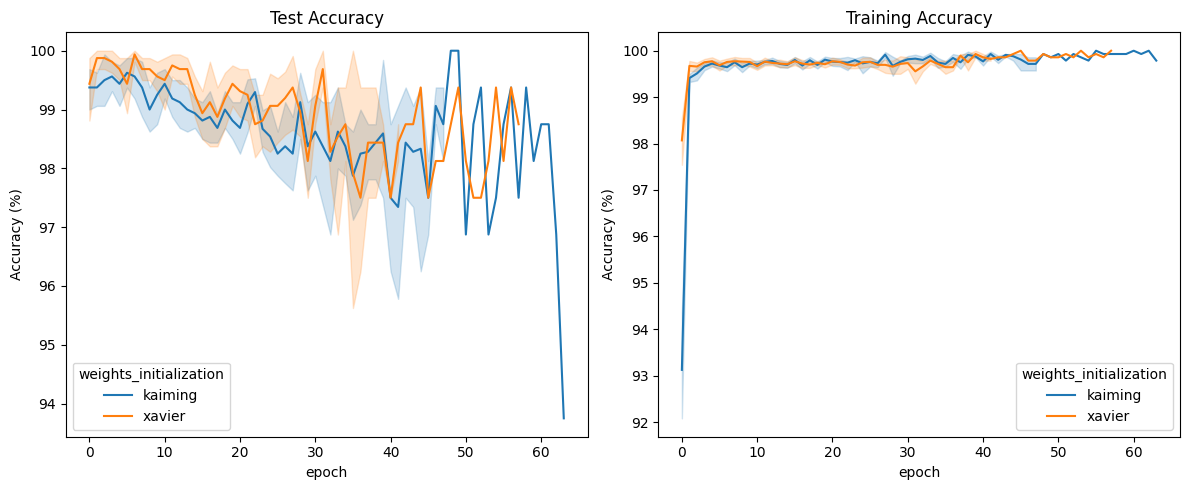

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(data=final_training_progress, x='epoch', y='test_acc', hue='weights_initialization', ax=ax1)
ax1.set_title('Test Accuracy')
ax1.set_ylabel('Accuracy (%)')

sns.lineplot(data=final_training_progress, x='epoch', y='train_acc', hue='weights_initialization', ax=ax2)
ax2.set_title('Training Accuracy')
ax2.set_ylabel('Accuracy (%)')

plt.tight_layout()
plt.show()

In [19]:
# get aggregate data (mean of the 10 experiments)
aggregated_data = (
    final_training_progress
    .drop('iteration', 'learning_rate', 'experiment_num')
    .group_by('weights_initialization','epoch')
    .agg(
        pl.all().mean().name.prefix('mean_')
    )
)

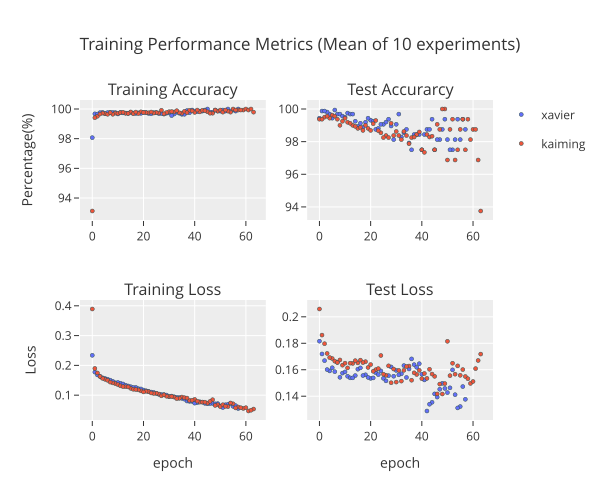

In [20]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=['Training Accuracy', 'Test Accurarcy', 'Training Loss', 'Test Loss']
    )

fig1 = px.scatter(aggregated_data, x='epoch', y='mean_train_acc', color='weights_initialization')
fig2 = px.scatter(aggregated_data, x='epoch', y='mean_test_acc', color='weights_initialization')
fig3 = px.scatter(aggregated_data, x='epoch', y='mean_train_loss', color='weights_initialization')
fig4 = px.scatter(aggregated_data, x='epoch', y='mean_test_loss', color='weights_initialization')

for trace in fig1.data:
  fig.add_trace(trace, row=1, col=1)

for trace in fig2.data:
  trace.showlegend=False
  fig.add_trace(trace, row=1, col=2)

for trace in fig3.data:
  trace.showlegend=False
  fig.add_trace(trace, row=2, col=1)

for trace in fig4.data:
  trace.showlegend=False
  fig.add_trace(trace, row=2, col=2)

fig.update_xaxes(title_text='epoch', row=2, col=1)
fig.update_xaxes(title_text='epoch', row=2, col=2)
fig.update_yaxes(title_text='Percentage(%)', row=1, col=1)
fig.update_yaxes(title_text='Loss', row=2, col=1)

fig.update_layout(
    title='Training Performance Metrics (Mean of 10 experiments)',
    template='ggplot2',
    width=600)

fig.update_traces(marker=dict(size=4, line=dict(width=0.5, color='darkslategray')))

fig

In [21]:
aggregate_per_experiment = (
    final_training_progress
    .group_by('weights_initialization', 'experiment_num')
    .agg(
        cs.exclude('epoch', 'iteration', 'learning_rate',).mean().name.prefix('mean_')
    )
)

aggregate_per_experiment.head()

weights_initialization,experiment_num,mean_train_loss,mean_train_acc,mean_test_loss,mean_test_acc
str,i32,f64,f64,f64,f64
"""xavier""",6,0.125952,99.675017,0.153528,99.337121
"""kaiming""",7,0.150408,99.386622,0.172127,98.806818
"""xavier""",5,0.137562,99.663826,0.158397,99.375
"""kaiming""",9,0.099945,99.6693,0.165714,98.681641
"""kaiming""",5,0.123431,99.608415,0.163504,99.070946


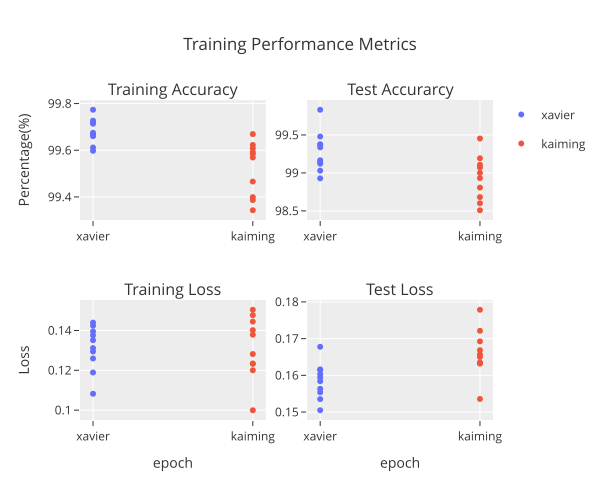

In [22]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=['Training Accuracy', 'Test Accurarcy', 'Training Loss', 'Test Loss']
    )

fig1 = px.scatter(aggregate_per_experiment, x='weights_initialization', y='mean_train_acc', color='weights_initialization')
fig2 = px.scatter(aggregate_per_experiment, x='weights_initialization', y='mean_test_acc', color='weights_initialization')
fig3 = px.scatter(aggregate_per_experiment, x='weights_initialization', y='mean_train_loss', color='weights_initialization')
fig4 = px.scatter(aggregate_per_experiment, x='weights_initialization', y='mean_test_loss', color='weights_initialization')

for trace in fig1.data:
  fig.add_trace(trace, row=1, col=1)

for trace in fig2.data:
  trace.showlegend=False
  fig.add_trace(trace, row=1, col=2)

for trace in fig3.data:
  trace.showlegend=False
  fig.add_trace(trace, row=2, col=1)

for trace in fig4.data:
  trace.showlegend=False
  fig.add_trace(trace, row=2, col=2)

fig.update_xaxes(title_text='epoch', row=2, col=1)
fig.update_xaxes(title_text='epoch', row=2, col=2)
fig.update_yaxes(title_text='Percentage(%)', row=1, col=1)
fig.update_yaxes(title_text='Loss', row=2, col=1)

fig.update_layout(
    title='Training Performance Metrics',
    template='ggplot2',
    width=600)

fig

Interpretation:
* there is overfitting towards as observed in test accuracy
* difference is small, but Xavier Initialization appears to slightly better or more stable than Kaiming, contrary to typical expectation for a ReLU network
* Why:
  * probably model isn't deep enough which is one of the benefits of Kaiming initialization is to prevent exploding/vanishing gradient in very deep network.
  * adam optimizer is very robust and adaptive. In this case, Adam optimize might be able to quickly overrides the substle difference by the initial scale
* to further test this, I could increase the complexity of the model.


In [23]:
final_training_progress.head()

iteration,epoch,train_loss,train_acc,test_loss,test_acc,learning_rate,weights_initialization,experiment_num
i64,i64,f64,f64,f64,f64,f64,str,i32
44,0,0.41755,91.619318,0.188663,99.375,0.01,"""kaiming""",1
88,1,0.181995,99.289773,0.167217,99.375,0.01,"""kaiming""",1
132,2,0.171063,99.573864,0.162229,100.0,0.01,"""kaiming""",1
176,3,0.159482,99.573864,0.167879,99.375,0.01,"""kaiming""",1
220,4,0.153637,99.786932,0.154997,99.375,0.01,"""kaiming""",1


In [24]:
aggregated_data_ci = (
    final_training_progress
    .group_by(['epoch', 'weights_initialization'])
    .agg([
        pl.col('test_acc').mean().alias('mean_test_acc'),
        pl.col('test_acc').std().alias('std_test_acc'),
        pl.col('test_acc').count().alias('n_experiments'),
        pl.col('train_acc').mean().alias('mean_train_acc'),
        pl.col('train_acc').std().alias('std_train_acc'),
    ])
    .with_columns([
        # Calculate 95% confidence interval margins
        (1.96 * pl.col('std_test_acc') / pl.col('n_experiments').sqrt()).alias('ci_test_acc'),
        (1.96 * pl.col('std_train_acc') / pl.col('n_experiments').sqrt()).alias('ci_train_acc'),
    ])
    .with_columns([
        # Calculate upper and lower bounds using the CI margins
        (pl.col('mean_test_acc') + pl.col('ci_test_acc')).alias('upper_test_acc'),
        (pl.col('mean_test_acc') - pl.col('ci_test_acc')).alias('lower_test_acc'),
        (pl.col('mean_train_acc') + pl.col('ci_train_acc')).alias('upper_train_acc'),
        (pl.col('mean_train_acc') - pl.col('ci_train_acc')).alias('lower_train_acc'),
    ])
    .sort(['weights_initialization', 'epoch'])
)

In [25]:
aggregated_data_ci.head()

epoch,weights_initialization,mean_test_acc,std_test_acc,n_experiments,mean_train_acc,std_train_acc,ci_test_acc,ci_train_acc,upper_test_acc,lower_test_acc,upper_train_acc,lower_train_acc
i64,str,f64,f64,u32,f64,f64,f64,f64,f64,f64,f64,f64
0,"""kaiming""",99.375,0.589256,10,93.125,1.986324,0.365224,1.231136,99.740224,99.009776,94.356136,91.893864
1,"""kaiming""",99.375,0.51031,10,99.410511,0.153609,0.316294,0.095208,99.691294,99.058706,99.505719,99.315303
2,"""kaiming""",99.5,0.768295,10,99.509943,0.240151,0.476194,0.148847,99.976194,99.023806,99.65879,99.361096
3,"""kaiming""",99.5625,0.421843,10,99.659091,0.133082,0.261461,0.082485,99.823961,99.301039,99.741576,99.576606
4,"""kaiming""",99.4375,0.547247,10,99.723011,0.118134,0.339187,0.07322,99.776687,99.098313,99.796232,99.649791


In [26]:
# practice with altair
accuracy_chart = (
    (
        alt.Chart(final_training_progress, title='Test Accuracy (%)')
        .mark_line()
        .encode(
            alt.X('epoch:Q'),
            # Define the scale and aggregation here
            alt.Y('test_acc:Q', aggregate='mean', scale=alt.Scale(domain=[90, 100])),
            alt.Color('weights_initialization:N'),

        )
    )
    +
    (
        alt.Chart(final_training_progress)
        .mark_errorband(extent='ci')
        .encode(
            alt.X('epoch:Q'),
            # No explicit scale needed here; it will share the scale from the line layer
            alt.Y('test_acc:Q'),
            alt.Color('weights_initialization:N'),
        )
    )
)

loss_chart = (
    (
        alt.Chart(final_training_progress, title='Test Loss')
        .mark_line()
        .encode(
            alt.X('epoch:Q'),
            # Define the scale and aggregation here
            alt.Y('test_loss:Q', aggregate='mean', scale=alt.Scale(domain=[0, 0.3])),
            alt.Color('weights_initialization:N'),
        )
    )
    +
    (
        alt.Chart(final_training_progress)
        .mark_errorband(extent='ci')
        .encode(
            alt.X('epoch:Q'),
            # No explicit scale needed here; it will share the scale from the line layer
            alt.Y('test_loss:Q'),
            alt.Color('weights_initialization:N'),
        )
    )
)


alt.hconcat(accuracy_chart, loss_chart).interactive()

alt.HConcatChart(...)